# Rotterdam Intersection Photo Filter

Filters all panoramic photos down to those within 55m of a road intersection
inside the Rotterdam ring.

All photo metadata is read from `image_index.csv` on the external HDD.
That file contains x/y coordinates in RD New, H3 folder cells, and pre-built
relative paths (`img_front`, `img_back`, etc.) that map directly to files on
the server — no shapefile or secondary metadata file is needed.

Every panorama faces **north** (`Pan = 0`), which is added as a column so that
notebook 04 can use it directly.

**Input files:**
- `D:\rotterdam_aiis_2025\vault-production\vault_v1\image_index.csv` — master photo index (coordinates + H3 server paths)
- `data/processed/intersections_merged.gpkg` — merged intersections (from notebook 01)
- `data/processed/rotterdam_boundary.gpkg` — Rotterdam boundary polygon (from notebook 00)

**Output files:**
- `data/processed/selected_photos_near_intersections.csv` — filtered photo list

**Depends on:** notebooks 00 and 01 must be run first.

**Coordinate system:** RD New (EPSG:28992) — coordinates are the `x`/`y` columns in `image_index.csv`.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

# Base project directory — all other paths are relative to this
PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections"

# --- Image mode ---
# "panorama"   : one 360° image per location → single filepath column (H3 + image_id), Pan = 0
# "directional": four shots per location (front/back/left/right) →
#                filepath_front/back/left/right columns + heading_* columns
IMAGE_MODE = "directional"  # change to "directional" to process the four-direction photos

# Input: master photo index with coordinates and H3 server paths.
# Prefer the external HDD when connected; fall back to the local copy if not.
HDD_INDEX_PATH   = r"D:\rotterdam_aiis_2025\vault-production\vault_v1\image_index.csv"
LOCAL_INDEX_PATH = os.path.join(PROJECT_DIR, "data", "raw", "image_index.csv")
INDEX_PATH = HDD_INDEX_PATH if os.path.exists(HDD_INDEX_PATH) else LOCAL_INDEX_PATH
print(f"Using image index: {INDEX_PATH}")

# Input: intersections and boundary prepared by notebooks 00 and 01
INTERSECTIONS_PATH = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
BOUNDARY_PATH      = os.path.join(PROJECT_DIR, "data", "processed", "rotterdam_boundary.gpkg")

# Output: filename reflects the active image mode so panorama and directional runs don't overwrite each other
OUTPUT_CSV = os.path.join(PROJECT_DIR, "data", "processed",
                          f"selected_photos_{IMAGE_MODE}.csv")
print(f"Output will be written to: {OUTPUT_CSV}")

# --- Filter parameters (shared with notebooks 01 and 04) ---
# Imported from pipeline_config.py — change values there and re-run notebook 01
# to propagate to the intersections .gpkg; this notebook reads max_dist_m from that file.
_config_dir = os.path.join(PROJECT_DIR, "notebooks", "pipeline")
if _config_dir not in sys.path:
    sys.path.insert(0, _config_dir)
from pipeline_config import (
    FALLBACK_BUFFER_M,    # outer radius (m) to use when max_dist_m is missing from .gpkg
    BUFFER_MARGIN_M,      # safety margin added on top of max_dist_m
    INNER_BUFFER_METERS,  # min distance from intersection centre — excludes photos inside the junction
)

print(f"Buffer params: fallback={FALLBACK_BUFFER_M}m, margin=+{BUFFER_MARGIN_M}m, inner={INNER_BUFFER_METERS}m")

CRS_RD = "EPSG:28992"     # RD New — Dutch national projection in metres

Using image index: D:\rotterdam_aiis_2025\vault-production\vault_v1\image_index.csv
Output will be written to: C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\selected_photos_directional.csv
Buffer params: fallback=55m, margin=+5m, inner=5m


## 1. Load image index CSV

Read `image_index.csv` and build a GeoDataFrame from the `x`/`y` columns.
The coordinates are already in RD New (EPSG:28992) — no reprojection needed.

In [2]:
# Read the master photo index — all coordinates, H3 folder paths, and relative
# image paths are in this single file
photos_df = pd.read_csv(INDEX_PATH)

# Build a GeoDataFrame from the x/y columns — already in RD New, no reprojection needed
photos_gdf = gpd.GeoDataFrame(
    photos_df,
    geometry=gpd.points_from_xy(photos_df["x"], photos_df["y"]),
    crs=CRS_RD
)

print(f"Total photos loaded: {len(photos_gdf):,}")
print(f"Columns: {list(photos_gdf.columns)}")
photos_gdf.head()

Total photos loaded: 617,579
Columns: ['image_id', 'x', 'y', 'day', 'month', 'year', 'trip_time', 'H3_8', 'H3_9', 'H3_10', 'img_front', 'img_back', 'img_left', 'img_right', 'heading_front', 'heading_right', 'heading_back', 'heading_left', 'geometry']


,image_id,x,y,day,month,year,trip_time,H3_8,H3_9,H3_10,img_front,img_back,img_left,img_right,heading_front,heading_right,heading_back,heading_left,geometry
0,1_00001,98448.887,438163.582,25,6,2024,2024-06-25 05:40:31,88196bb733fffff,89196bb7337ffff,8a196bb73347fff,88196bb733fffff/89196bb7337ffff/8a196bb73347ff...,88196bb733fffff/89196bb7337ffff/8a196bb73347ff...,88196bb733fffff/89196bb7337ffff/8a196bb73347ff...,88196bb733fffff/89196bb7337ffff/8a196bb73347ff...,235.433253,325.433253,55.433253,145.433253,POINT (9.84e+04 4.38e+05)
1,1_00002,98444.797,438160.764,25,6,2024,2024-06-25 05:40:31,88196bb733fffff,89196bb7337ffff,8a196bb73347fff,88196bb733fffff/89196bb7337ffff/8a196bb73347ff...,88196bb733fffff/89196bb7337ffff/8a196bb73347ff...,88196bb733fffff/89196bb7337ffff/8a196bb73347ff...,88196bb733fffff/89196bb7337ffff/8a196bb73347ff...,235.433253,325.433253,55.433253,145.433253,POINT (9.84e+04 4.38e+05)
2,1_00003,98441.052,438157.438,25,6,2024,2024-06-25 05:40:31,88196bb733fffff,89196bb7337ffff,8a196bb7334ffff,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,189.362428,279.362428,9.362428,99.362428,POINT (9.84e+04 4.38e+05)
3,1_00004,98440.239,438152.507,25,6,2024,2024-06-25 05:40:31,88196bb733fffff,89196bb7337ffff,8a196bb7334ffff,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,189.362428,279.362428,9.362428,99.362428,POINT (9.84e+04 4.38e+05)
4,1_00005,98441.301,438147.582,25,6,2024,2024-06-25 05:40:31,88196bb733fffff,89196bb7337ffff,8a196bb7334ffff,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,88196bb733fffff/89196bb7337ffff/8a196bb7334fff...,167.094685,257.094685,347.094685,77.094685,POINT (9.84e+04 4.38e+05)


In [3]:
# Build filepath column(s) based on the selected image mode.
# In PANORAMA mode: each location has one 360° image; construct path from H3 folders + image_id.
# In DIRECTIONAL mode: each location has four shots; paths are already stored in img_* columns.
if IMAGE_MODE == "panorama":
    photos_gdf["filepath"] = (
        photos_gdf["H3_8"].astype(str) + "/" +
        photos_gdf["H3_9"].astype(str) + "/" +
        photos_gdf["H3_10"].astype(str) + "/" +
        photos_gdf["image_id"].astype(str) + ".jpg"
    )
    print(f"Panorama filepath built. Example: {photos_gdf['filepath'].iloc[0]}")
else:
    # img_front/back/left/right already contain the full relative server path
    for direction in ["front", "back", "left", "right"]:
        photos_gdf[f"filepath_{direction}"] = photos_gdf[f"img_{direction}"]
    print(f"Directional filepaths kept from img_* columns.")
    print(f"  Example front: {photos_gdf['filepath_front'].iloc[0]}")

print(f"IMAGE_MODE='{IMAGE_MODE}' | {len(photos_gdf):,} rows")

Directional filepaths kept from img_* columns.
  Example front: 88196bb733fffff/89196bb7337ffff/8a196bb73347fff/1_00001_front.jpg
IMAGE_MODE='directional' | 617,579 rows


## 2. Add Pan = 0 (north-facing convention)

The data provider confirmed that the centre of every panorama in this dataset
faces **north**, meaning the camera heading is always 0°. Adding this as a column
now means notebook 04 can read Pan directly from the output CSV without needing
to merge in a separate file.

In [4]:
# All photos in this dataset are north-facing (Pan = 0), regardless of image mode.
photos_gdf["Pan"] = 0.0
print("Pan = 0.0 added (all photos face north).")

Pan = 0.0 added (all photos face north).


## 3. Load Rotterdam boundary and intersections

Rotterdam boundary loaded.
Intersections loaded: 4,715


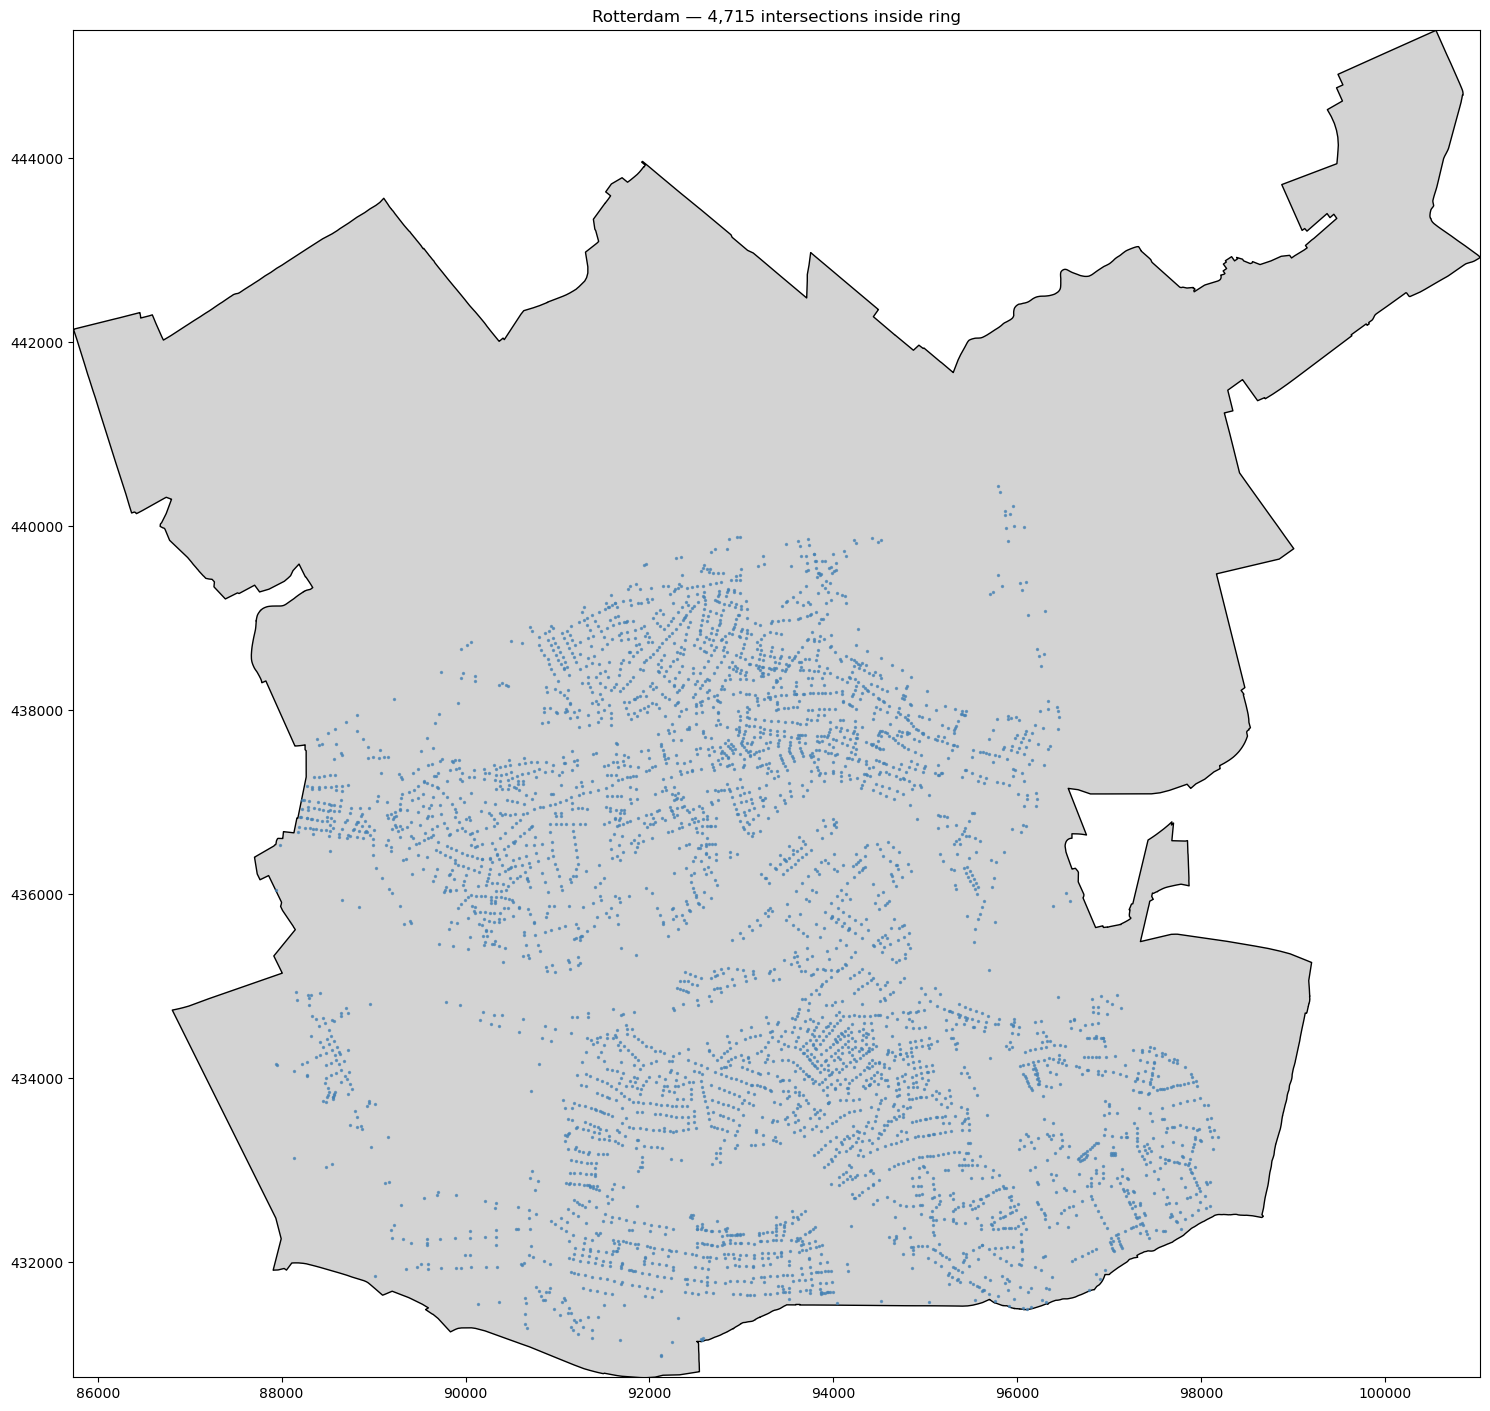

In [5]:
# Load boundary and intersections saved by notebooks 00 and 01
rotterdam     = gpd.read_file(BOUNDARY_PATH)
intersections = gpd.read_file(INTERSECTIONS_PATH)

print(f"Rotterdam boundary loaded.")
print(f"Intersections loaded: {len(intersections):,}")

# Get bounding box of Rotterdam for consistent plot axes
minx, miny, maxx, maxy = rotterdam.total_bounds

# Quick plot to verify the intersection data looks correct
fig, ax = plt.subplots(figsize=(15, 15))
rotterdam.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=1)
intersections.plot(ax=ax, color="steelblue", markersize=2, alpha=0.7)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title(f"Rotterdam — {len(intersections):,} intersections inside ring")
plt.tight_layout()
plt.show()

## 4. Buffer intersections — annular ring (inner 5m excluded)

In [6]:
print("Creating buffers...")
buffered = intersections[["geometry"]].copy()

# Use per-intersection outer radius if max_dist_m is available; otherwise use the fixed fallback.
# max_dist_m = cluster_radius + CAPTURE_BUFFER_M, computed in notebook 01.
# Large merged junctions (dual carriageways) get a wider capture zone automatically.
# Adding BUFFER_MARGIN_M ensures photos right at the boundary edge are not missed by the sjoin.
if "max_dist_m" in intersections.columns:
    outer_radii = intersections["max_dist_m"] + BUFFER_MARGIN_M
    print(f"Using per-intersection outer radii from max_dist_m "
          f"(range: {outer_radii.min():.1f}–{outer_radii.max():.1f}m, "
          f"margin: +{BUFFER_MARGIN_M}m)")
else:
    outer_radii = FALLBACK_BUFFER_M + BUFFER_MARGIN_M
    print(f"max_dist_m not found — using fixed outer radius: {outer_radii}m")

# Annular buffer: outer disk minus the inner disk.
# Photos within INNER_BUFFER_METERS of the intersection centre are excluded
# because they were taken from inside the intersection itself.
buffered["geometry"] = (
    intersections.geometry.buffer(outer_radii)
    .difference(intersections.geometry.buffer(INNER_BUFFER_METERS))
)

# Keep intersection centre coordinates for later bearing calculations
buffered["inter_x"] = intersections.geometry.x
buffered["inter_y"] = intersections.geometry.y
buffered = buffered.reset_index(drop=True)

print(f"Done. {len(buffered):,} intersection buffers created.")

Creating buffers...
Using per-intersection outer radii from max_dist_m (range: 30.0–45.9m, margin: +5m)
Done. 4,715 intersection buffers created.


## 5. Visualise — Rotterdam boundary + intersection buffers

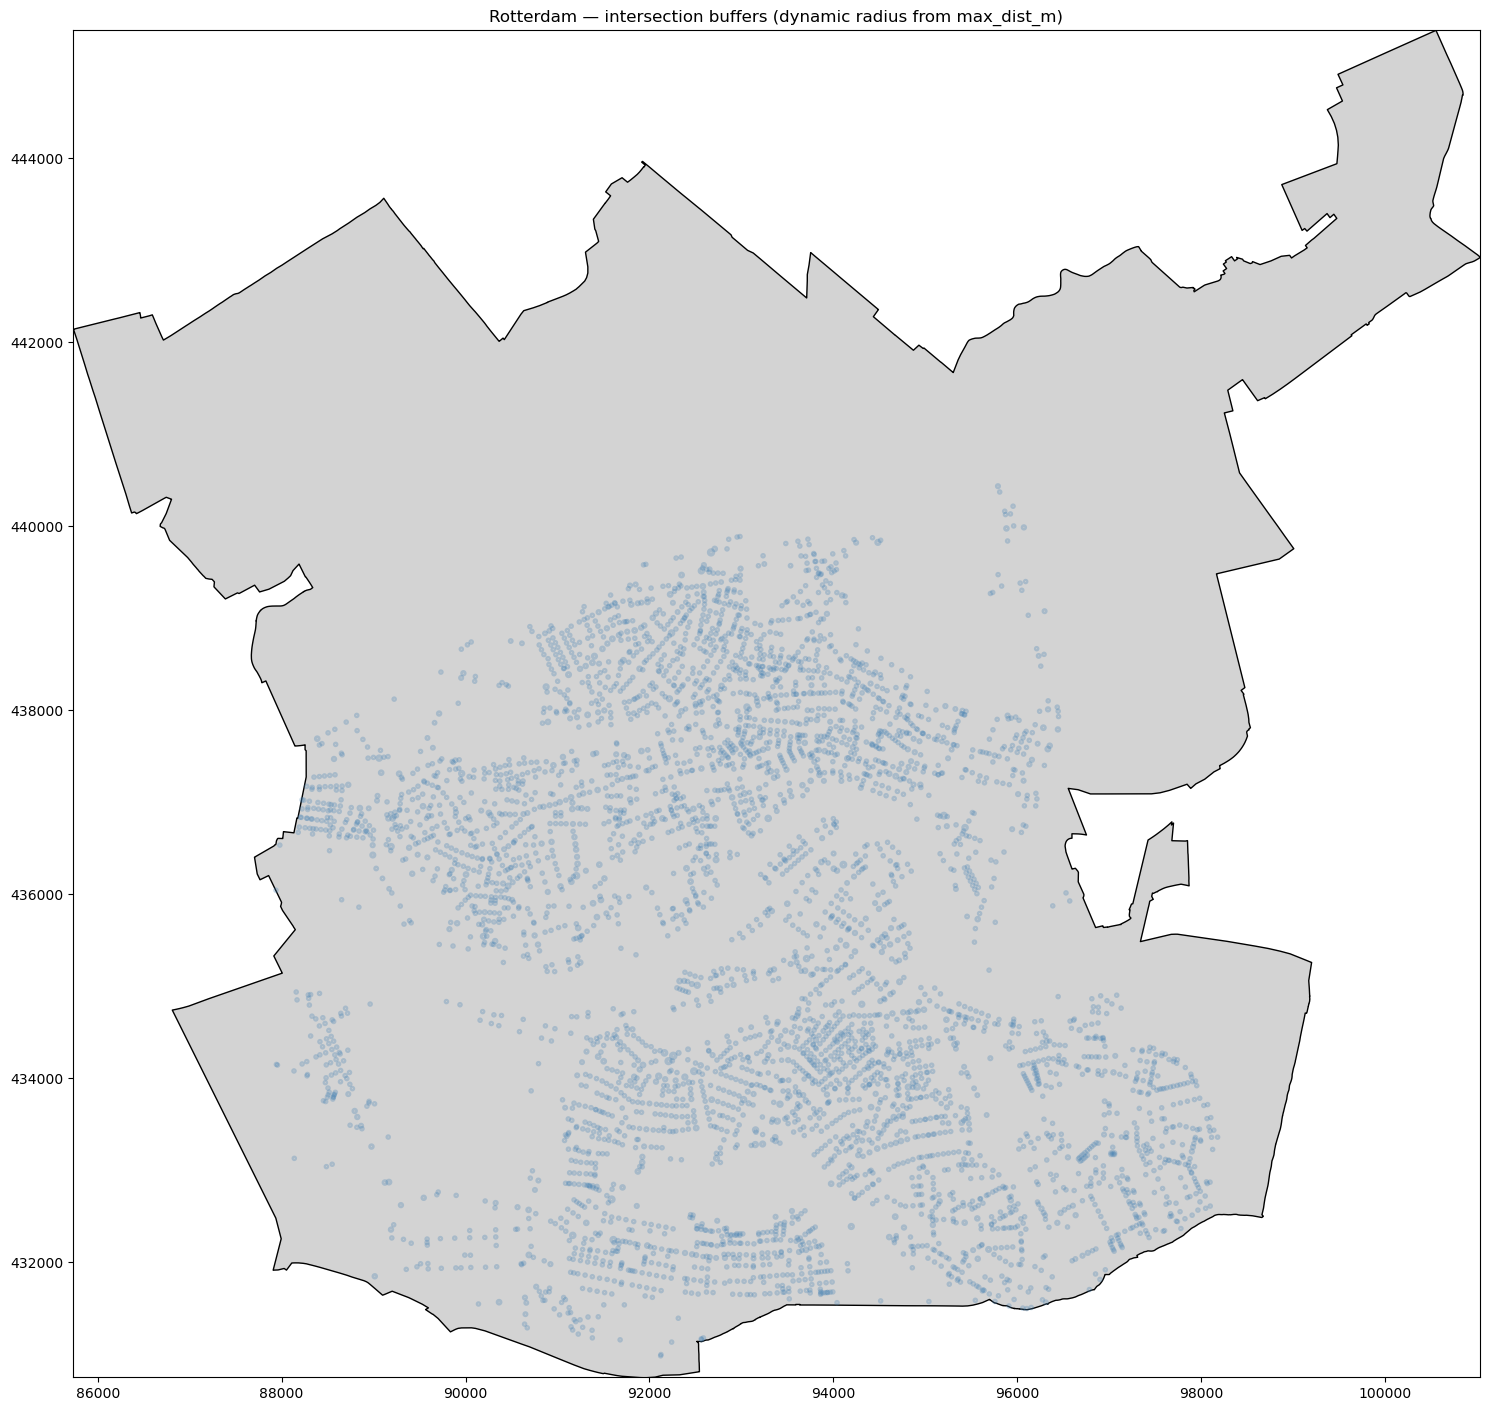

In [7]:
fig, ax = plt.subplots(figsize=(15, 15))
rotterdam.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=1)
buffered.plot(ax=ax, color="steelblue", alpha=0.3)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Rotterdam — intersection buffers (dynamic radius from max_dist_m)")
plt.tight_layout()
plt.show()

## 6. Select photos near intersections

In [8]:
import math

print("Running spatial filter...")

CHUNK_SIZE = 10_000
n_photos   = len(photos_gdf)
# Use ceiling division so the last partial chunk is always included.
# Floor division (n_photos // CHUNK_SIZE) would silently skip the tail:
# e.g. 617,579 // 10,000 = 61, leaving photos 610,000–617,578 unprocessed.
n_chunks   = max(1, math.ceil(n_photos / CHUNK_SIZE))

matched_indices = []
for i in range(n_chunks):
    start = i * CHUNK_SIZE
    end   = min(start + CHUNK_SIZE, n_photos)
    chunk = photos_gdf.iloc[start:end]

    # Find all photos whose point falls within any intersection buffer.
    # sjoin uses an R-tree spatial index — much faster than .within() on a merged polygon.
    result = gpd.sjoin(chunk, buffered, how="inner", predicate="within")
    matched_indices.append(result.index)

    if (i + 1) % 10 == 0 or (i + 1) == n_chunks:
        pct = (i + 1) / n_chunks * 100
        print(f"  {i+1}/{n_chunks} chunks done ({pct:.0f}%)")

# Combine all matched indices — a photo can overlap multiple buffers, so deduplicate
all_matched = pd.Index(np.concatenate(matched_indices)).unique()
selected = photos_gdf.loc[all_matched].copy()

print(f"\nPhotos near intersections: {len(selected):,}")
print(f"Total photos:              {len(photos_gdf):,}")
print(f"Selection rate:            {len(selected)/len(photos_gdf)*100:.1f}%")

Running spatial filter...
  10/62 chunks done (16%)
  20/62 chunks done (32%)
  30/62 chunks done (48%)
  40/62 chunks done (65%)
  50/62 chunks done (81%)
  60/62 chunks done (97%)
  62/62 chunks done (100%)

Photos near intersections: 101,609
Total photos:              617,579
Selection rate:            16.5%


## 7. Visualise selected photos on the map

C:\Users\Thijs\AppData\Local\Temp\ipykernel_23960\3644744796.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Thijs\anaconda3\envs\afstuderen\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


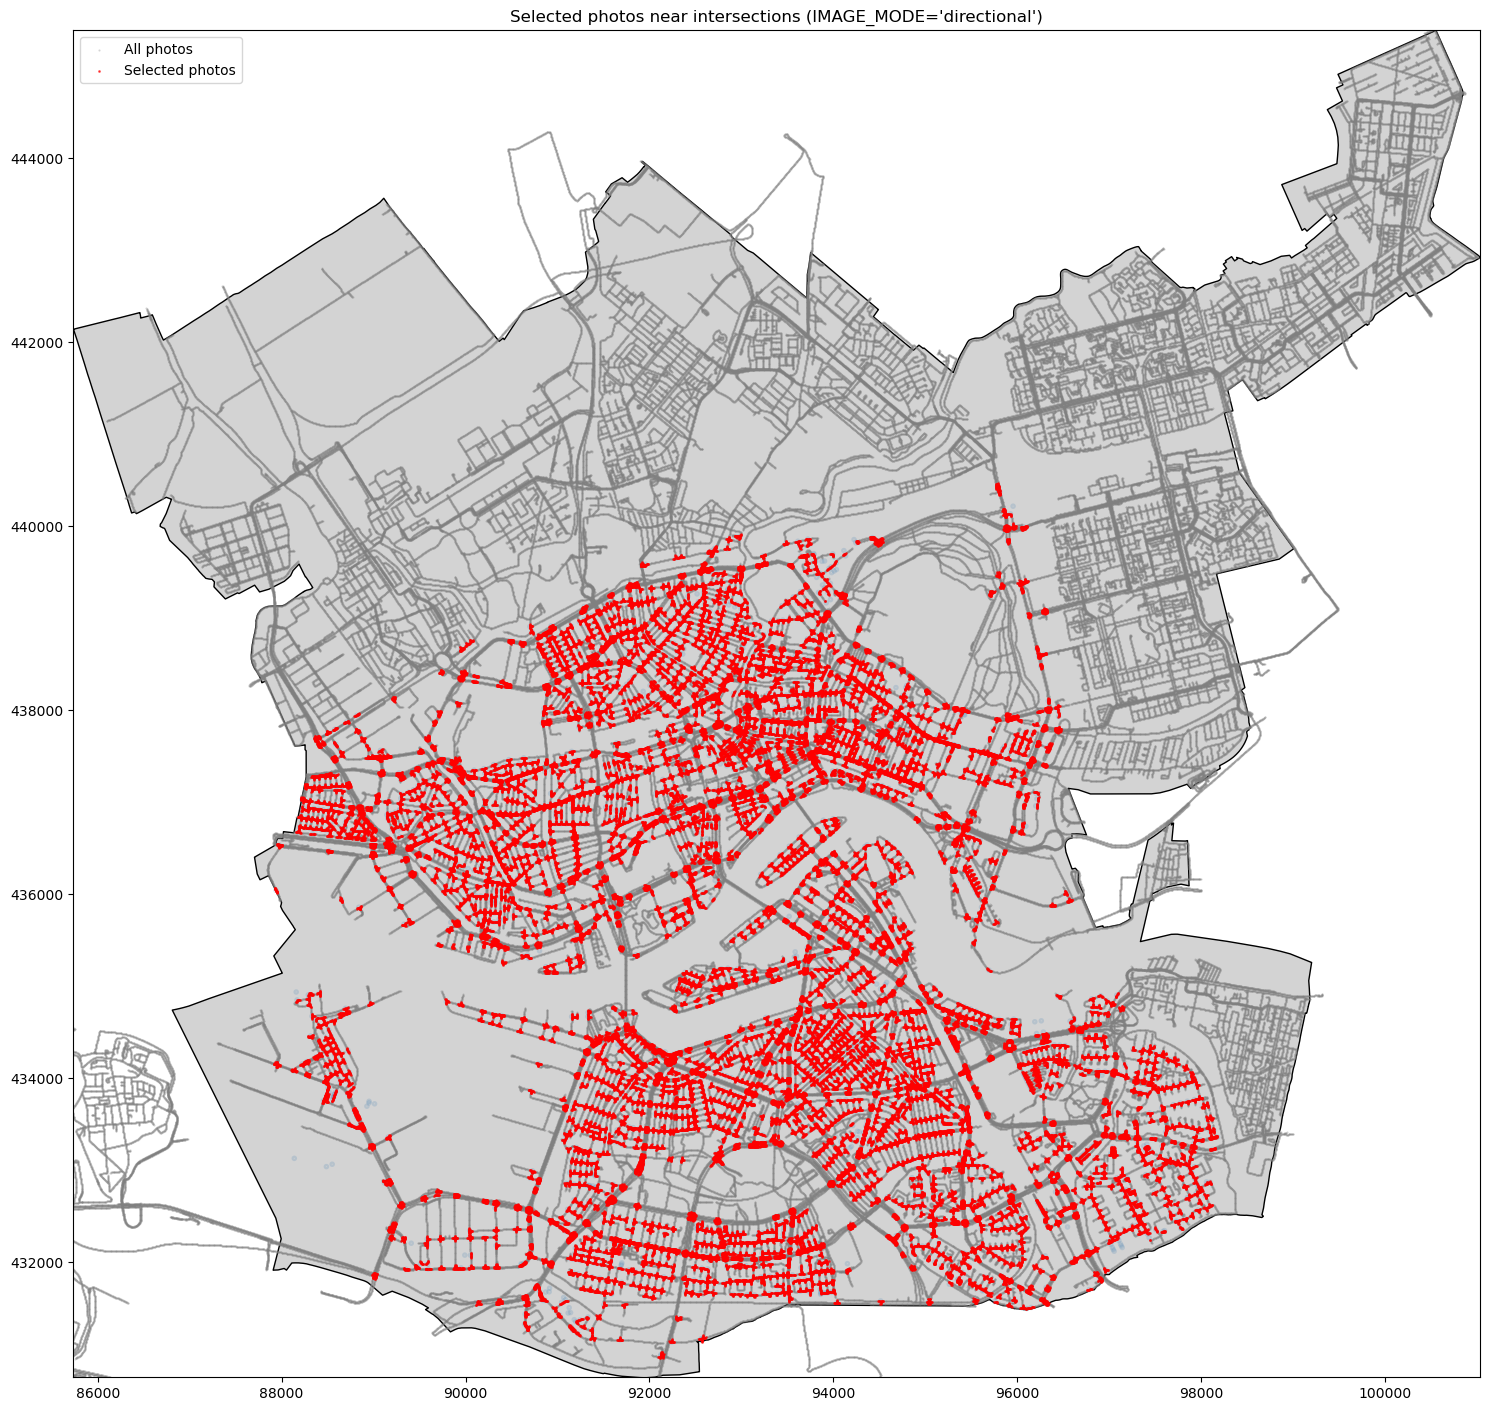

In [9]:
fig, ax = plt.subplots(figsize=(15, 15))
rotterdam.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=1)
buffered.plot(ax=ax, color="steelblue", alpha=0.2)
photos_gdf.plot(ax=ax, color="grey", markersize=0.3, alpha=0.3, label="All photos")
selected.plot(ax=ax, color="red", markersize=1, alpha=0.6, label="Selected photos")
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.legend()
ax.set_title(f"Selected photos near intersections (IMAGE_MODE='{IMAGE_MODE}')")
plt.tight_layout()
plt.show()

## 8. Export result

Exported columns depend on `IMAGE_MODE`:
- **panorama**: `image_id`, `filepath`, `x`, `y`, `Pan`
- **directional**: `image_id`, `filepath_front/back/left/right`, `heading_front/right/back/left`, `x`, `y`, `Pan`

Output filename reflects the active mode (e.g. `selected_photos_panorama.csv`).

In [10]:
# Define export columns based on image mode
if IMAGE_MODE == "panorama":
    export_cols = ["image_id", "filepath", "x", "y", "Pan"]
else:
    export_cols = [
        "image_id",
        "filepath_front", "filepath_back", "filepath_left", "filepath_right",
        "heading_front", "heading_right", "heading_back", "heading_left",
        "x", "y", "Pan"
    ]

# Drop any export columns that don't exist (safety guard for mode mismatches)
export_cols = [c for c in export_cols if c in selected.columns]

selected[export_cols].to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(selected):,} rows to: {OUTPUT_CSV}")
print(f"Columns: {export_cols}")
selected[export_cols].head()

Saved 101,609 rows to: C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\selected_photos_directional.csv
Columns: ['image_id', 'filepath_front', 'filepath_back', 'filepath_left', 'filepath_right', 'heading_front', 'heading_right', 'heading_back', 'heading_left', 'x', 'y', 'Pan']


,image_id,filepath_front,filepath_back,filepath_left,filepath_right,heading_front,heading_right,heading_back,heading_left,x,y,Pan
569,1_00570,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,277.606016,7.606016,97.606016,187.606016,96475.157,437789.145,0.0
570,1_00571,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,277.606016,7.606016,97.606016,187.606016,96470.207,437789.806,0.0
571,1_00572,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,277.743983,7.743983,97.743983,187.743983,96465.258,437790.479,0.0
572,1_00573,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,277.861949,7.861949,97.861949,187.861949,96460.300,437791.171,0.0
573,1_00574,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,88196bb55dfffff/89196bb55dbffff/8a196bb55d87ff...,277.861949,7.861949,97.861949,187.861949,96455.361,437791.853,0.0
